Meta data shape: (112120, 11)
Dataset shape with paths: (112120, 12)
Train label counts:
 label
dot      44848
nodot    44848
Name: count, dtype: int64
Test label counts:
 label
dot      11212
nodot    11212
Name: count, dtype: int64
[train] 2000/89696 (2.2%)
[train] 4000/89696 (4.5%)
[train] 6000/89696 (6.7%)
[train] 8000/89696 (8.9%)
[train] 10000/89696 (11.1%)
[train] 12000/89696 (13.4%)
[train] 14000/89696 (15.6%)
[train] 16000/89696 (17.8%)
[train] 18000/89696 (20.1%)
[train] 20000/89696 (22.3%)
[train] 22000/89696 (24.5%)
[train] 24000/89696 (26.8%)
[train] 26000/89696 (29.0%)
[train] 28000/89696 (31.2%)
[train] 30000/89696 (33.4%)
[train] 32000/89696 (35.7%)
[train] 34000/89696 (37.9%)
[train] 36000/89696 (40.1%)
[train] 38000/89696 (42.4%)
[train] 40000/89696 (44.6%)
[train] 42000/89696 (46.8%)
[train] 44000/89696 (49.1%)
[train] 46000/89696 (51.3%)
[train] 48000/89696 (53.5%)
[train] 50000/89696 (55.7%)
[train] 52000/89696 (58.0%)
[train] 54000/89696 (60.2%)
[train] 56000/8969

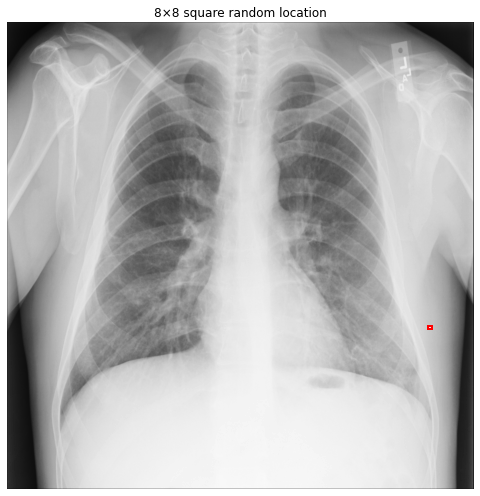

Saved train manifest to /home/jupyter-yin10/Image_Analysis/ResNet50/s8/train_manifest.csv
Saved test manifest to /home/jupyter-yin10/Image_Analysis/ResNet50/s8/test_manifest.csv
Train rows: 89696 | dot: 44848 | nodot: 44848
Test rows: 22424 | dot: 11212 | nodot: 11212


In [1]:
import os, shutil, random, hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from pathlib import Path
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed

# =====================================================
# PATHS
# =====================================================
WORK_DIR = Path("/home/jupyter-yin10/Image_Analysis")
IMG_DIR  = Path("/data0/NIH-CXR14/images")
RAW_CSV  = Path("/data0/NIH-CXR14/Data_Entry_2017_v2020.csv")

# Output root (S8)
out_root = Path("/home/jupyter-yin10/Image_Analysis/ResNet50/s8")

# Metadata exports (kept consistent with your other shapes)
SAMPLE_CSV        = WORK_DIR / "meta_NIH-CXR14.csv"
SAMPLE_WITH_PATHS = WORK_DIR / "meta_NIH-CXR14_with_paths.csv"

# =====================================================
# SETTINGS (same pattern as other shapes)
# =====================================================
SEED = 42
SQUARE_SIZE = 8
INCLUDE_BLACK_PROB = 0.0
WORK_DIR.mkdir(parents=True, exist_ok=True)

# =====================================================
# LOAD METADATA + ADD PATHS
# =====================================================
df_meta = pd.read_csv(RAW_CSV)
df_meta.to_csv(SAMPLE_CSV, index=False)

df = df_meta.copy()
df["Image Path"] = (IMG_DIR.as_posix().rstrip("/") + "/") + df["Image Index"].astype(str)
df.to_csv(SAMPLE_WITH_PATHS, index=False)

print("Meta data shape:", df_meta.shape)
print("Dataset shape with paths:", df.shape)

# =====================================================
# HELPERS (deterministic seeds)
# =====================================================
def _seed_from_name(name: str, base_seed: int) -> int:
    h = hashlib.sha256()
    h.update(str(base_seed).encode("utf-8"))
    h.update(b"::")
    h.update(name.encode("utf-8"))
    return int.from_bytes(h.digest()[:8], "little", signed=False)

def choose_random_top_left(img_path: Path, square_size: int, base_seed: int, key_str: str) -> tuple[int, int]:
    with Image.open(img_path) as im:
        w, h = im.size
    s = square_size
    xmin, xmax = 0, max(0, w - s)
    ymin, ymax = 0, max(0, h - s)
    if xmax < xmin or ymax < ymin:
        return (0, 0)
    seed = _seed_from_name(key_str, base_seed)
    rng = random.Random(seed)
    x = rng.randint(xmin, xmax)
    y = rng.randint(ymin, ymax)
    return (x, y)

def compute_intensity_range(img_path: Path, span: int = 20) -> tuple[int, int, int]:
    with Image.open(img_path) as img:
        img = img.convert("L")
        hist = img.histogram()[:256]
    mode_x = int(np.argmax(hist))
    lo = max(0, mode_x - span)
    hi = min(255, mode_x + span)
    return lo, hi, mode_x

def add_square_patch(
    img_path: Path,
    out_path: Path,
    top_left: tuple[int, int],
    patch_size: int,
    base_seed: int,
    key_str: str,
    lo: int,
    hi: int,
    include_black_prob: float = 0.0,
):
    with Image.open(img_path) as img:
        img = img.convert("L")
        arr = np.array(img)

    H, W = arr.shape
    x, y = top_left
    s = int(patch_size)

    if x < 0 or y < 0 or x + s > W or y + s > H:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        Image.fromarray(arr).save(out_path)
        return

    pix_seed = _seed_from_name("pixels::" + key_str, base_seed)
    rng = np.random.default_rng(pix_seed)

    patch = rng.integers(lo, hi + 1, size=(s, s), dtype=np.uint8)

    if include_black_prob > 0:
        mask = rng.random((s, s)) < include_black_prob
        patch[mask] = 0

    arr[y:y + s, x:x + s] = patch

    out_path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(arr).save(out_path)

def copy_or_link(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.link(src, dst)
    except OSError:
        try:
            os.symlink(src, dst)
        except OSError:
            shutil.copyfile(src, dst)

# =====================================================
# SPLIT + BALANCE LABELS
# =====================================================
def label_balanced(dframe: pd.DataFrame, seed: int):
    n = len(dframe)
    idx = list(range(n))
    random.Random(seed).shuffle(idx)
    half = n // 2
    with_dot = set(idx[:half])
    dframe["label"] = ["dot" if i in with_dot else "nodot" for i in range(n)]
    return dframe

df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n_total = len(df)
n_train = int(n_total * 0.8)

train_df = df.iloc[:n_train].copy()
test_df  = df.iloc[n_train:].copy()

train_df = label_balanced(train_df, SEED)
test_df  = label_balanced(test_df,  SEED)

print("Train label counts:\n", train_df["label"].value_counts())
print("Test label counts:\n", test_df["label"].value_counts())

# =====================================================
# WRITE IMAGES (parallel)
# =====================================================
def _process_row(r, split: str):
    src = Path(r["Image Path"])
    dst = out_root / split / r["label"] / Path(r["Image Index"]).name

    if r["label"] == "dot":
        base_seed = SEED if split == "train" else SEED + 1

        top_left = choose_random_top_left(
            img_path=src,
            square_size=SQUARE_SIZE,
            base_seed=base_seed,
            key_str=str(dst.name),
        )

        lo, hi, _mode = compute_intensity_range(img_path=src, span=20)

        add_square_patch(
            img_path=src,
            out_path=dst,
            top_left=top_left,
            patch_size=SQUARE_SIZE,
            base_seed=base_seed,
            key_str=str(dst.name),
            lo=lo,
            hi=hi,
            include_black_prob=INCLUDE_BLACK_PROB,
        )
    else:
        copy_or_link(src, dst)

def materialize_split_parallel(dframe: pd.DataFrame, split: str, workers: int = 8, log_every: int = 2000):
    total = len(dframe)
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = [ex.submit(_process_row, r, split) for _, r in dframe.iterrows()]
        for i, f in enumerate(as_completed(futs), 1):
            _ = f.result()
            if i % log_every == 0 or i == total:
                print(f"[{split}] {i}/{total} ({i/total:.1%})")

shutil.rmtree(out_root, ignore_errors=True)
out_root.mkdir(parents=True, exist_ok=True)

materialize_split_parallel(train_df, "train", workers=8)
materialize_split_parallel(test_df, "test", workers=8)

print(f"Done. Written images to {out_root}")

# =====================================================
# VERIFY COUNTS + VISUAL CHECK
# =====================================================
def count_pngs(folder: Path):
    return sum(1 for _ in folder.glob("*.png"))

train_dot   = out_root / "train" / "dot"
train_nodot = out_root / "train" / "nodot"
test_dot    = out_root / "test"  / "dot"
test_nodot  = out_root / "test"  / "nodot"

print("Counts:")
print("Train/dot:", count_pngs(train_dot))
print("Train/nodot:", count_pngs(train_nodot))
print("Test/dot:", count_pngs(test_dot))
print("Test/nodot:", count_pngs(test_nodot))

dot_images = list(train_dot.glob("*.png"))
if len(dot_images) == 0:
    raise RuntimeError("No dot images found in train/dot to verify.")

img_path = dot_images[1] if len(dot_images) > 1 else dot_images[0]
base_seed = SEED  # train determinism
x, y = choose_random_top_left(img_path=img_path, square_size=SQUARE_SIZE, base_seed=base_seed, key_str=str(img_path.name))
lo, hi, mode_x = compute_intensity_range(img_path=img_path, span=20)

img = Image.open(img_path).convert("L")
arr = np.array(img)
patch_vals = arr[y:y + SQUARE_SIZE, x:x + SQUARE_SIZE]

print(f"{SQUARE_SIZE}x{SQUARE_SIZE} patch top-left (x,y)=({x},{y})")
print(f"Histogram mode: {mode_x}, range: [{lo}, {hi}]")
print("Patch intensities:\n", patch_vals)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(arr, cmap="gray")
ax.add_patch(Polygon(
    [(x - 0.5, y - 0.5), (x + SQUARE_SIZE - 0.5, y - 0.5),
     (x + SQUARE_SIZE - 0.5, y + SQUARE_SIZE - 0.5), (x - 0.5, y + SQUARE_SIZE - 0.5)],
    fill=False, edgecolor="red", linewidth=2
))
ax.set_title(f"{SQUARE_SIZE}×{SQUARE_SIZE} square random location")
ax.axis("off")
plt.tight_layout()
plt.show()

# =====================================================
# MANIFESTS
# =====================================================
LABEL_MAP = {"dot": 1, "nodot": 0}

def make_manifest(split: str, root: Path, label_map: dict, pattern: str = "*.png") -> pd.DataFrame:
    rows = []
    for label_name, label_id in label_map.items():
        folder = root / split / label_name
        if not folder.exists():
            print("Folder not found:", folder)
            continue
        for p in sorted(folder.glob(pattern)):
            rows.append({"path": str(p), "label": int(label_id)})
    return pd.DataFrame(rows, columns=["path", "label"])

train_manifest = make_manifest("train", out_root, LABEL_MAP)
test_manifest  = make_manifest("test",  out_root, LABEL_MAP)

train_manifest_path = out_root / "train_manifest.csv"
test_manifest_path  = out_root / "test_manifest.csv"

train_manifest.to_csv(train_manifest_path, index=False)
test_manifest.to_csv(test_manifest_path, index=False)

print("Saved train manifest to", train_manifest_path)
print("Saved test manifest to", test_manifest_path)
print("Train rows:", len(train_manifest), "| dot:", (train_manifest["label"] == 1).sum(), "| nodot:", (train_manifest["label"] == 0).sum())
print("Test rows:", len(test_manifest), "| dot:", (test_manifest["label"] == 1).sum(), "| nodot:", (test_manifest["label"] == 0).sum())


Device: cuda
GPU: NVIDIA GeForce RTX 3090
Rows: train 80726 val 8970 test 22424
Train label counts:
 label
1    40363
0    40363
Name: count, dtype: int64
Val   label counts:
 label
1    4485
0    4485
Name: count, dtype: int64
Test  label counts:
 label
1    11212
0    11212
Name: count, dtype: int64


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train 1/10:   0%|          | 0/2523 [00:00<?, ?it/s]

Val loss 1/10:   0%|          | 0/281 [00:00<?, ?it/s]

Val probs:   0%|          | 0/281 [00:00<?, ?it/s]

...

Val loss 10/10:   0%|          | 0/281 [00:00<?, ?it/s]

Val probs:   0%|          | 0/281 [00:00<?, ?it/s]

Best val AUC: 0.9906842453912397
Saved best checkpoint: /home/jupyter-yin10/Image_Analysis/ResNet50/s8/runs/resnet50_imagenet_v2/best.pt


Test probs:   0%|          | 0/701 [00:00<?, ?it/s]


Test results (s8)
Accuracy: 0.9723956475205138
Precision: 0.9831250570099426
Recall: 0.9612914734213343
F1: 0.9720856820744082
ROC AUC: 0.9921530523715162

Confusion matrix:
 [[11027   185]
 [  434 10778]]

Classification report:
               precision    recall  f1-score   support

           0     0.9621    0.9835    0.9727     11212
           1     0.9831    0.9613    0.9721     11212

    accuracy                         0.9724     22424
   macro avg     0.9726    0.9724    0.9724     22424
weighted avg     0.9726    0.9724    0.9724     22424



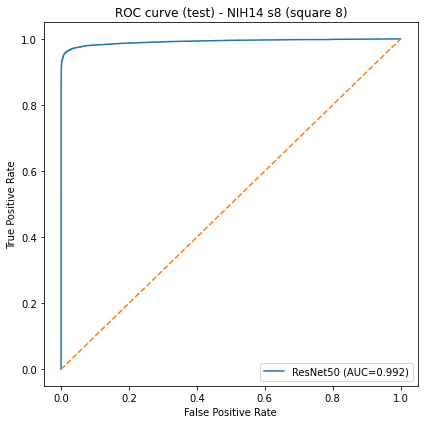

Saved ROC plot to: /home/jupyter-yin10/Image_Analysis/ResNet50/s8/runs/resnet50_imagenet_v2/roc_test.png
Saved metrics to: /home/jupyter-yin10/Image_Analysis/ResNet50/s8/runs/resnet50_imagenet_v2/test_metrics.json


In [1]:
# ResNet50 training for NIH14 square8 (s8) with tqdm progress bars + ETA
# Dataset: /home/jupyter-yin10/Image_Analysis/ResNet50/s8
# Outputs: best checkpoint, ROC plot, metrics JSON

import os, json, random
from pathlib import Path

# ----------------------------
# GPU selection (set before torch uses CUDA)
# ----------------------------
# If using P6000 kernel and want to force it (visible idx depends on kernel env):
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import models
from torchvision.models import ResNet50_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ----------------------------
# Config (keep identical to other shapes)
# ----------------------------
SEED = 42
IMG_SIZE = 448
BATCH_SIZE = 32
EPOCHS = 10
LR = 3e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4  # if you see worker issues in Jupyter, set this to 0

DATA_ROOT = Path("/home/jupyter-yin10/Image_Analysis/ResNet50/s8")
TRAIN_CSV = DATA_ROOT / "train_manifest.csv"
TEST_CSV  = DATA_ROOT / "test_manifest.csv"

OUT_DIR = DATA_ROOT / "runs" / "resnet50_imagenet_v2"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = OUT_DIR / "best.pt"
ROC_PATH = OUT_DIR / "roc_test.png"
METRICS_PATH = OUT_DIR / "test_metrics.json"

# ----------------------------
# Reproducibility
# ----------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ----------------------------
# Load manifests and make val split
# ----------------------------
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

if not {"path", "label"}.issubset(train_df.columns):
    raise ValueError("train_manifest.csv must have columns: path,label")
if not {"path", "label"}.issubset(test_df.columns):
    raise ValueError("test_manifest.csv must have columns: path,label")

train_df, val_df = train_test_split(
    train_df,
    test_size=0.10,
    random_state=SEED,
    stratify=train_df["label"]
)

print("Rows:", "train", len(train_df), "val", len(val_df), "test", len(test_df))
print("Train label counts:\n", train_df["label"].value_counts())
print("Val   label counts:\n", val_df["label"].value_counts())
print("Test  label counts:\n", test_df["label"].value_counts())

# ----------------------------
# Dataset
# ----------------------------
class ManifestDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        path = row["path"]
        label = int(row["label"])

        img = Image.open(path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, label

# ----------------------------
# Transforms
# ----------------------------
weights = ResNet50_Weights.IMAGENET1K_V2
imagenet_mean = weights.transforms().mean
imagenet_std  = weights.transforms().std

train_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((IMG_SIZE, IMG_SIZE)),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((IMG_SIZE, IMG_SIZE)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_ds = ManifestDataset(train_df, transform=train_transform)
val_ds   = ManifestDataset(val_df,   transform=eval_transform)
test_ds  = ManifestDataset(test_df,  transform=eval_transform)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

# ----------------------------
# Model
# ----------------------------
model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ----------------------------
# Helpers
# ----------------------------
def _to_device(x, y):
    x = x.to(device, non_blocking=True)
    y = y.to(device, non_blocking=True)
    return x, y

def train_one_epoch(loader: DataLoader, epoch: int):
    model.train()
    total_loss = 0.0
    n = 0
    pbar = tqdm(loader, desc=f"Train {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = _to_device(x, y)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        n += bs
        pbar.set_postfix(loss=(total_loss / max(1, n)))
    return total_loss / max(1, n)

@torch.no_grad()
def eval_loss(loader: DataLoader, epoch: int, name: str = "Val"):
    model.eval()
    total_loss = 0.0
    n = 0
    pbar = tqdm(loader, desc=f"{name} loss {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = _to_device(x, y)
        logits = model(x)
        loss = criterion(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        n += bs
        pbar.set_postfix(loss=(total_loss / max(1, n)))
    return total_loss / max(1, n)

@torch.no_grad()
def predict_probs(loader: DataLoader, name: str = "Eval"):
    model.eval()
    all_probs = []
    all_labels = []
    pbar = tqdm(loader, desc=f"{name} probs", leave=False)
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

# ----------------------------
# Train with best checkpoint by val ROC AUC
# ----------------------------
best_val_auc = -1.0
history = []

epoch_pbar = tqdm(range(1, EPOCHS + 1), desc="Epochs")
for epoch in epoch_pbar:
    tr_loss = train_one_epoch(train_loader, epoch)
    va_loss = eval_loss(val_loader, epoch, name="Val")

    va_probs, va_labels = predict_probs(val_loader, name="Val")
    try:
        va_auc = roc_auc_score(va_labels, va_probs)
    except ValueError:
        va_auc = float("nan")

    history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": va_loss, "val_auc": float(va_auc)})
    epoch_pbar.set_postfix(train_loss=tr_loss, val_loss=va_loss, val_auc=va_auc)

    if np.isfinite(va_auc) and va_auc > best_val_auc:
        best_val_auc = va_auc
        torch.save({"model_state": model.state_dict(), "epoch": epoch, "val_auc": float(va_auc)}, CKPT_PATH)

print("Best val AUC:", best_val_auc)
print("Saved best checkpoint:", CKPT_PATH)

# ----------------------------
# Test evaluation
# ----------------------------
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

test_probs, test_labels = predict_probs(test_loader, name="Test")
test_pred = (test_probs >= 0.5).astype(int)

acc = accuracy_score(test_labels, test_pred)
prec, rec, f1, _ = precision_recall_fscore_support(test_labels, test_pred, average="binary", zero_division=0)
cm = confusion_matrix(test_labels, test_pred).tolist()

try:
    test_auc = roc_auc_score(test_labels, test_probs)
except ValueError:
    test_auc = float("nan")

print("\nTest results (s8)")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("ROC AUC:", test_auc)
print("\nConfusion matrix:\n", np.array(cm))
print("\nClassification report:\n", classification_report(test_labels, test_pred, digits=4, zero_division=0))

# ----------------------------
# ROC curve plot
# ----------------------------
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ResNet50 (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (test) - NIH14 s8 (square 8)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(ROC_PATH, dpi=200)
plt.show()

print("Saved ROC plot to:", ROC_PATH)

# ----------------------------
# Save metrics
# ----------------------------
metrics = {
    "dataset": "NIH14",
    "task": "s8_square8_dot_vs_nodot",
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "best_val_auc": float(best_val_auc),
    "test_accuracy": float(acc),
    "test_precision": float(prec),
    "test_recall": float(rec),
    "test_f1": float(f1),
    "test_roc_auc": float(test_auc),
    "confusion_matrix": cm,
    "best_ckpt_epoch": int(ckpt.get("epoch", -1)),
    "history": history
}

with open(METRICS_PATH, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved metrics to:", METRICS_PATH)
